<a href="https://colab.research.google.com/github/markajbell/BH/blob/main/Stats_sec_1k.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [ ]:
!pip install pyvis

import pandas as pd
import numpy as np
import json
import os
import glob
import re


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.1 MB/s eta 0:00:00


In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option("display.max_rows", None, "display.max_columns", None)
pd.set_option('display.max_colwidth', None)

# Download and process Files

In [ ]:
!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure1k.json

if not os.path.exists('/content/adsync'):
    os.makedirs('/content/adsync')
    print("/content/adsync directory created.")
else:
    print("/content/adsync directory already exists.")

path = "/content/adsync"

!mv secure1k.json /content/adsync



data = {}
json_files = glob.glob(os.path.join(path, "*.json"))
for file in json_files:
    filename = os.path.basename(file).replace(".json", "")
    suf = filename.split("_")[-1]

    with open(file, 'r', encoding='utf-8') as f:
        content = json.load(f)

    if "data" in content:
        if suf in data:
            data[f"{suf}"].extend(content["data"])
            #print(f" The key 'data' was found in {f}.")
        else:
            data[f"{suf}"] = content["data"]
            #print(f" The key 'data' was found in {f}.")
    else:
        print(f"Warning: The key 'data' was not found in {f}.")

--2025-08-07 09:54:10--  https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure1k.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1314149 (1.3M) [text/plain]
Saving to: ‘secure1k.json’

secure1k.json       100%[===================>]   1.25M  4.70MB/s    in 0.3s    

2025-08-07 09:54:11 (4.70 MB/s) - ‘secure1k.json’ saved [1314149/1314149]

/content/adsync directory created.


In [ ]:
# prompt: if the type column = "node" save that record into a pandas dataframe called nodes, if the type = "relationship' then save to a pandas dataframe called edges


df = pd.DataFrame(data[suf])
nodes = df[df['type'] == 'node'].copy()
edges = df[df['type'] == 'relationship'].copy()
nodes['id'] = nodes['id'].astype(int)

In [ ]:
# prompt: for every record in "nodes" create a l1, l2 and l3 column for the values in "nodes.labels" eg. for record 1 l1=Base, l2=OU and l3 would be null

import pandas as pd
def extract_labels(labels):
    # Ensure labels is a list
    if not isinstance(labels, list):
        return [None, None, None]

    l1 = labels[0] if len(labels) > 0 else None
    l2 = labels[1] if len(labels) > 1 else None
    l3 = labels[2] if len(labels) > 2 else None
    return [l1, l2, l3]

# Apply the function to create the new columns
nodes[['l1', 'l2', 'l3']] = nodes['labels'].apply(lambda x: pd.Series(extract_labels(x)))

In [ ]:
nodes = nodes.drop(columns=['start', 'end', 'label', 'labels'])
# edges = edges.drop(columns=['labels'])

In [ ]:
edges.head()

,id,labels,properties,type,start,end,label
1297,r_0,NaN,{},relationship,"{'id': '0', 'labels': ['Base', 'Domain']}","{'id': '1', 'labels': ['Base', 'OU']}",Contains
1298,r_1,NaN,{},relationship,"{'id': '0', 'labels': ['Base', 'Domain']}","{'id': '2', 'labels': ['Base', 'OU']}",Contains
1299,r_2,NaN,{},relationship,"{'id': '0', 'labels': ['Base', 'Domain']}","{'id': '3', 'labels': ['Base', 'OU']}",Contains
1300,r_3,NaN,{},relationship,"{'id': '1', 'labels': ['Base', 'OU']}","{'id': '4', 'labels': ['Base', 'OU']}",Contains
1301,r_4,NaN,{},relationship,"{'id': '1', 'labels': ['Base', 'OU']}","{'id': '5', 'labels': ['Base', 'OU']}",Contains


In [ ]:
edges['source'] = edges['start'].apply(lambda x: x.get('id'))
edges['source_node'] = edges['start'].apply(lambda x: x.get('labels')[1] if isinstance(x.get('labels'), list) and len(x.get('labels')) > 1 else None)

edges['target'] = edges['end'].apply(lambda x: x.get('id'))
edges['target_node'] = edges['end'].apply(lambda x: x.get('labels')[1] if isinstance(x.get('labels'), list) and len(x.get('labels')) > 1 else None)

edges = edges.drop(columns=['properties', 'start', 'end', 'id', 'labels'])
edges['id'] = np.arange(len(edges)).astype('int64')
edges = edges.reset_index(drop=True)
nodes['weight'] = 1
edges = edges[['id', 'source', 'source_node', 'target', 'target_node', 'type','label']]
display(edges.head())
edges.info()

,id,source,source_node,target,target_node,type,label
0,0,0,Domain,1,OU,relationship,Contains
1,1,0,Domain,2,OU,relationship,Contains
2,2,0,Domain,3,OU,relationship,Contains
3,3,1,OU,4,OU,relationship,Contains
4,4,1,OU,5,OU,relationship,Contains


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3974 entries, 0 to 3973
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           3974 non-null   int64 
 1   source       3974 non-null   object
 2   source_node  3974 non-null   object
 3   target       3974 non-null   object
 4   target_node  3974 non-null   object
 5   type         3974 non-null   object
 6   label        3974 non-null   object
dtypes: int64(1), object(6)
memory usage: 217.5+ KB


In [ ]:
#edges = edges.drop(columns=['id'])
nodes.info()
nodes.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1297 entries, 0 to 1296
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          1297 non-null   int64 
 1   properties  1297 non-null   object
 2   type        1297 non-null   object
 3   l1          1297 non-null   object
 4   l2          1297 non-null   object
 5   l3          6 non-null      object
 6   weight      1297 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 81.1+ KB


,id,properties,type,l1,l2,l3,weight
0,0,"{'domain': 'MARK.LOCAL', 'name': 'MARK.LOCAL', 'highvalue': True, 'objectid': 'S-1-5-21-883232822-274137685-4173207997', 'distinguishedname': 'DC=MARK,DC=LOCAL', 'functionallevel': '2012', 'owned': False}",node,Base,Domain,None,1
1,1,"{'domain': 'MARK.LOCAL', 'name': 'Admin@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-cdca22b1-d164-4ec1-8233-45c0ea9044ac', 'distinguishedname': 'OU=ADMIN,DC=MARK,DC=LOCAL', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}",node,Base,OU,None,1
2,2,"{'domain': 'MARK.LOCAL', 'name': 'Tier 1 Servers@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-f6d49f51-1ea3-4d9c-93a1-0b591b59c7e9', 'distinguishedname': 'OU=TIER 1 SERVERS,DC=MARK,DC=LOCAL', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}",node,Base,OU,None,1
3,3,"{'domain': 'MARK.LOCAL', 'name': 'Tier 2@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-5de20ac8-e7ff-4f05-b597-268af392400e', 'distinguishedname': 'OU=TIER 2,DC=MARK,DC=LOCAL', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}",node,Base,OU,None,1
4,4,"{'domain': 'MARK.LOCAL', 'name': 'T0 Admin@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-f249f685-d5e0-4dad-b5b5-7f723c41ca1e', 'distinguishedname': 'OU=T0 ADMIN,DC=MARK,DC=LOCAL', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}",node,Base,OU,None,1


In [ ]:
lastnode=(len(str(nodes['id'].iloc[-1])))

new_node_id = int('9' * lastnode)

print(f"The new node ID is: {new_node_id}")

The new node ID is: 9999


In [ ]:
#prompt: create a new record in nodes where id=new_node_id, properties = {'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-99999', 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False}, type=node, l1=ALL_T0, l2=ALL_T0, l3=ALL_T0

# Create a dictionary with the new record's data
new_node_data = {
    'id': new_node_id,
    'properties': {'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-' + str(new_node_id), 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False},
    'type': 'node',
    'l1': 'ALL_T0',
    'l2': 'ALL_T0',
    'l3': 'ALL_T0',
    'weight': int(100) # Assuming a default weight, you can adjust if needed
}
#new_node_data

# Convert the dictionary to a DataFrame
new_node_df = pd.DataFrame([new_node_data])

# Concatenate the new DataFrame with the existing nodes DataFrame
nodes = pd.concat([nodes, new_node_df], ignore_index=True)

# Display the last few rows to confirm the addition
print("Nodes DataFrame after adding the new record:")
#display(nodes.tail())

Nodes DataFrame after adding the new record:


In [ ]:
print(nodes[nodes['id'] == 26])
# print(nodes[nodes['id'] == 15])
# print(nodes[nodes['id'] == 26])
# print(nodes[nodes['id'] == 27])
# print(nodes[nodes['id'] == 637])
# print(nodes[nodes['id'] == 581])
# print(nodes[nodes['id'] == 633])
# print(nodes[nodes['id'] == 869])

    id  \
26  26   

                                                                                                                                                                                                                                                                                                                       properties  \
26  {'domain': 'MARK.LOCAL', 'name': 'T2 Enabled User Accounts@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-dd1b08e8-140d-49e3-ab56-1551c008827a', 'distinguishedname': 'OU=T2 ENABLED USER ACCOUNTS,DC=MARK,DC=LOCAL', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}   

    type    l1  l2    l3  weight  
26  node  Base  OU  None       1  


In [ ]:
#1/0
# tier0_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 0' in x.get('distinguishedname', ''))]['id'].tolist()
# tier0_node_ids
tier0_node_ids = []

tier0_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: (
            any(
                term in x.get('distinguishedname', '')
                for term in ['TIER 0', 'Tier 0', 'T0', 'TIER0','CN=Enterprise Admins,', 'CN=Domain Admins,', 'CN=Administrator,']
            )
            or  # Use 'or' to combine the conditions
            (
                re.search(r'.*-5[0-9]{2}$', x.get('objectid', '')) is not None and
                x.get('highvalue', False) == True and
                x.get('admincount', False) == True
            )
        )
    )
]['id'].tolist()

print(f"tier 0 (after checking filtered_nodes): {len(tier0_node_ids)}")

tier 0 (after checking filtered_nodes): 52


In [ ]:
tier1_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 1', 'Tier 1', 'T1']
        )
    ) & (~nodes['id'].isin(tier0_node_ids)) # Add this condition to exclude Tier 0 nodes
]['id'].tolist()

tier2_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 2', 'Tier 2', 'T2']

        )
    ) & (~nodes['id'].isin(tier0_node_ids)) # Add this condition to exclude Tier 0 nodes
]['id'].tolist()

print(f"tier 0 ",len(tier0_node_ids))
# tier1_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 1' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 1 ",len(tier1_node_ids))

# tier2_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 2' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 2 ",len(tier2_node_ids))


tier 0  52
tier 1  57
tier 2  939


In [ ]:
# Iterate through nodes and add a 'Tier0' column
nodes['Tier0'] = 0  # Initialize 'Tier0' column with 0
nodes['Tier1'] = 0  # Initialize 'Tier0' column with 0
nodes['Tier2'] = 0  # Initialize 'Tier0' column with 0

# Set 'Tier0' to 1 if node id is in tier0_node_ids
nodes.loc[nodes['id'].isin(tier0_node_ids), 'Tier0'] = 1

# Set 'Tier1' to 1 if node id is in tier1_node_ids
nodes.loc[nodes['id'].isin(tier1_node_ids), 'Tier1'] = 1

# Set 'Tier2' to 1 if node id is in tier2_node_ids
nodes.loc[nodes['id'].isin(tier2_node_ids), 'Tier2'] = 1

# Display the updated nodes DataFrame (optional)
# display(nodes.head())
# display(nodes.tail())

In [ ]:
tier0_count = nodes[nodes['Tier0'] == 1].shape[0]
tier1_count = nodes[nodes['Tier1'] == 1].shape[0]
tier2_count = nodes[nodes['Tier2'] == 1].shape[0]

print(f"Number of nodes in Tier 0: {tier0_count}")
print(f"Number of nodes in Tier 1: {tier1_count}")
print(f"Number of nodes in Tier 2: {tier2_count}")

Number of nodes in Tier 0: 52
Number of nodes in Tier 1: 57
Number of nodes in Tier 2: 939


In [ ]:
# import pandas as pd

# len(tier0_node_ids)
# tier0_node_ids = pd.DataFrame(tier0_node_ids)

In [ ]:

for value in tier0_node_ids:
    if value  == new_node_id:
        nodes.loc[nodes['id'] == value, 'weight'] = 100
    else:
        nodes.loc[nodes['id'] == value, 'weight'] = 20

for value in tier1_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 10

for value in tier2_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 5


In [ ]:
edges.tail()

,id,source,source_node,target,target_node,type,label
3969,3969,65,Group,3,OU,relationship,GenericAll
3970,3970,66,Group,1,OU,relationship,GenericAll
3971,3971,66,Group,3,OU,relationship,GenericAll
3972,3972,60,Group,101,OU,relationship,GenericAll
3973,3973,66,Group,101,OU,relationship,GenericAll


In [ ]:
# prompt: for each value in tier0_node_ids add a new record in edges where start = value and end = new_node_id, label=TIER0,weight=100 id=id+1

# Get the maximum existing edge ID
max_edge_id = edges['id'].max()
max_edge_id
i=1
new_edges = []
for i, tier0_id in enumerate(tier0_node_ids):
    new_edge = {
        'type': 'relationship',  # Assuming type is always 'relationship' for edges
        'source': tier0_id,
        'source_node': 'TIER0',
        'target_node': 'TIER0',
        'target': new_node_id,
        'label': 'TIER0',
        'weight': 100,
        'id': max_edge_id + i + 1 # Assign a unique ID
    }
    new_edges.append(new_edge)

# Convert the list of new edges to a DataFrame
new_edges_df = pd.DataFrame(new_edges)

# Concatenate the new edges DataFrame with the existing edges DataFrame
edges = pd.concat([edges, new_edges_df], ignore_index=True)

# Display the last few rows to confirm the addition
print("Edges DataFrame after adding new TIER0 edges:")
#display(edges.tail(266))

Edges DataFrame after adding new TIER0 edges:


In [ ]:
# Apply the weights based on the 'label' column

def assign_weight(label):
    if label == "GenericAll":
        return 9
    elif label == "Owns":
        return 10
    elif label == "GenericWrite":
        return 2
    elif label == "AllExtendedRights":
        return 6
    elif label == "CanRDP":
        return 2
    elif label == "Contains":
        return 2
    elif label == "DCSync":
        return 8
    elif label == "WriteDacl":
        return 5
    elif label == "WriteOwner":
        return 7
    elif label == "AddKeyCredentialLink":
        return 6
    elif label == "AdminTo":
        return 8
    elif label == "MemberOf":
        return 2
    elif label == "CanPSRemote":
        return 2
    elif label == "ExecuteDCOM":
        return 2
    elif label == "GPLink":
        return 3
    elif label == "HasSession":
        return 9
    elif label == "ReadLAPSPassword":
        return 2
    elif label == "GetChanges":
        return 3
    elif label == "GetChangesAll":
        return 3
    elif label == "AddSelf":
        return 3
    elif label == "ForceChangePassword":
        return 3
    elif label == "AddMember":
        return 5
    elif label == "AllowedToDelegate":
        return 5
    elif label == "AllowedToAct":
        return 4
    elif label == "TIER0":
        return 100
    else:
        return 1 # Default weight for other labels

edges['weight'] = edges['label'].apply(assign_weight)

# Display the updated edges_all DataFrame with the 'weight' column
print("\nEdges_all DataFrame with weight column:")
#edges.head()
#clear_output()
#edges.tail()


Edges_all DataFrame with weight column:


In [ ]:
# prompt: create a unique id for each row, make sure it is of type int64
#edges = edges.drop(columns=['id'])
import numpy as np
#edges['id'] = np.arange(len(edges)).astype('int64')
#edges.head()
edges['id'] = edges['id'].astype('int64')
edges['source'] = edges['source'].astype('int64')
edges['target'] = edges['target'].astype('int64')
edges['weight'] = edges['weight'].astype('int64')
# edges.info()
# display(edges.head())
# display(edges.tail())

In [ ]:
tier0_node_ids = pd.DataFrame(tier0_node_ids)
tier2_node_ids = pd.DataFrame(tier2_node_ids)
tier1_node_ids = pd.DataFrame(tier1_node_ids)
tier1_node_ids = tier1_node_ids.rename(columns={0: 'id'})
tier0_node_ids = tier0_node_ids.rename(columns={0: 'id'})
tier2_node_ids = tier2_node_ids.rename(columns={0: 'id'})


In [ ]:
# # Check if edges['source'] is contained in tier2_node_ids and count the matches
count_matching_edges = edges[edges['source'].isin(tier2_node_ids['id'])].shape[0]

print(f"Number of records where edge['source'] is in tier2_node_ids: {count_matching_edges}")
# tier0_node_ids.info()


Number of records where edge['source'] is in tier2_node_ids: 2710


In [ ]:
selected_edges_t0 = edges[edges['source'].isin(tier2_node_ids['id']) & (edges['target'].isin(tier0_node_ids['id'])) & (~edges['source'].isin(tier0_node_ids['id'])) & (~edges['target'].isin(tier2_node_ids['id']))]
#scratch = selected_edges[selected_edges['weight'] == 8]
print(len(selected_edges_t0))
selected_nodes = nodes[nodes['id'].isin(tier2_node_ids['id'])]
print(len(selected_nodes))

57
939


In [ ]:
# tier2_node_ids.info()
# len(edges)

# Dijkstra

In [ ]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add nodes with their weights
for index, row in selected_nodes.iterrows():
    # Ensure node IDs are integers when adding to the graph
    G.add_node(int(row['id']), weight=row['weight'])

# Add edges with their weights
for index, row in selected_edges_t0.iterrows():
    G.add_edge(row['source'], row['target'], weight=row['weight'])

# Compute shortest paths from each source node to all reachable nodes
shortest_paths = {}
for source in G.nodes():
    # Use single_source_dijkstra_path to find paths from one source to all others
    shortest_paths[source] = nx.single_source_dijkstra_path(G, source)

# Filter out paths from a node to itself and store in a new dictionary
shortest_paths_filtered = {
    source: {
        target: path
        for target, path in paths.items()
        if source != target
        #if target in tier0_node_ids
        #if source in tier2_node_ids
    }
    for source, paths in shortest_paths.items()
}
len(shortest_paths_filtered)

# Print the shortest paths (optional)
# for source, paths in shortest_paths_filtered.items():
#   if paths:
#     #print(f"Shortest paths from node {source}:")
#     for target, path in paths.items():
#         #print(f"  To node {target}: {path}")
#         ShortestPath = source, target, path
#        # print(ShortestPath)

952

In [ ]:
#tier2_node_ids = pd.DataFrame(tier2_node_ids)
#

In [ ]:
def get_edge_weight(start_node, end_node):
    # Find the corresponding edge in the 'edges' DataFrame
    edge = edges[(edges['source'] == start_node) & (edges['target'] == end_node)]
    if not edge.empty:
        # Assuming there is only one edge with this start and end for simplicity in path finding
        # If multiple edges exist, you might need to adjust based on which edge is part of the shortest path calculation
        return edge.iloc[0]['weight']

#     if not edge.empty:
# # Return the weight from the resulting DataFrame
#         return edge['weight'].values[0]
#     else:
#         return None

shortest_paths_list = []
for source, paths in shortest_paths_filtered.items():
    if paths:
        for target, path in paths.items():
#            get_edge_weight(source, target)
            shortest_paths_list.append({
                'source': int(source),
                'target': int(target),
                'path': path,
                'weight': get_edge_weight(source, target)
            })

# Convert the list of dictionaries to a DataFrame
#shortest_paths_list = pd.DataFrame(shortest_paths_list)

# #shortest_paths_list.info()
# #short = shortest_paths_list[shortest_paths_list['target'].isin(tier2_node_ids)]
# #short1 = short[~short['source'].isin(tier0_node_ids)]
# #len(short)

In [ ]:
# shortest_paths_list = pd.DataFrame(shortest_paths_list)
# shortest_paths_list.info()

In [ ]:
#tier0_node_ids.info()

In [ ]:
display(edges[edges['source'] == 286])

,id,source,source_node,target,target_node,type,label,weight
513,513,286,User,38,Group,relationship,MemberOf,2
514,514,286,User,40,Group,relationship,MemberOf,2
515,515,286,User,59,Group,relationship,MemberOf,2
516,516,286,User,60,Group,relationship,MemberOf,2
517,517,286,User,65,Group,relationship,MemberOf,2
518,518,286,User,66,Group,relationship,MemberOf,2
519,519,286,User,72,Group,relationship,MemberOf,2
520,520,286,User,75,Group,relationship,MemberOf,2
522,522,286,User,36,Group,relationship,MemberOf,2
540,540,286,User,64,Group,relationship,MemberOf,2


In [ ]:
import pandas as pd
shortest_paths_list = pd.DataFrame(shortest_paths_list)
#short= shortest_paths_list[shortest_paths_list['source'] isin tier2_node_ids]

#tier2_node_ids = pd.DataFrame(tier2_node_ids)

def get_edge_weight(start_node, end_node):
    # Find the corresponding edge in the 'edges' DataFrame
    edge = edges[(edges['source'] == start_node) & (edges['target'] == end_node)]
    # if not edge.empty:
    #     # Assuming there is only one edge with this start and end for simplicity in path finding
    #     # If multiple edges exist, you might need to adjust based on which edge is part of the shortest path calculation
    return edge.iloc[0]['weight']

# Calculate the total weight for each shortest path

shortest_paths_with_weight = []

# Iterate through the DataFrame 'short1' using 'iterrows()'
for index, path_info in shortest_paths_list.iterrows():
    total_weight = 0
# The path is expected to be a list of node IDs
    path = path_info['path']
    source = path_info['source']
    target = path_info['target']

# Ensure that 'path' is a list; you may need to adjust this if 'path' is a string
    if isinstance(path, list):
    # Iterate through the path to get the edges
        for i in range(len(path) - 1):
            start_node = path[i]
            end_node = path[i + 1]
        # Assuming you have a way to get the weight of the edge between start_node and end_node
        # For example, if you have a function or a mapping for edge weights
            edge_weight = get_edge_weight(start_node, end_node) # Define this function to retrieve the weight
            total_weight += edge_weight
            shortest_paths_with_weight.append({'source': source, 'target': target, 'path': path, 'total_weight': total_weight})

# Append the result (path and its total weight) to the list
#shortest_paths_with_weight.append({source: source, target: target, path: path, 'total_weight': total_weight})

df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight).copy()
#df_shortest_paths_with_weight = df1[(df1['target'].isin(tier0_node_ids)) ]#& (df1['source'].isin(tier2_node_ids)) & (~df1['source'].isin(tier0_node_ids)) & (~df1['target'].isin(tier2_node_ids))]
#d = df_max[(df_max['source'].isin(tier2_node_ids)) & (df_max['target'].isin(tier0_node_ids)) & (~df_max['source'].isin(tier0_node_ids)) & (~df_max['target'].isin(tier2_node_ids))]
# At this point, shortest_paths_with_weight will contain all paths and their corresponding weights
len(df_shortest_paths_with_weight)

57

In [ ]:
# nodevalue = 5262
# is_in_tier2 = nodevalue in tier2_node_ids.values
# print(f"Does tier2_node_ids contain {nodevalue}: {is_in_tier2}")

In [ ]:
# type(tier2_node_ids)
# type(tier2_node_ids[0])
# df1.info()

In [ ]:
# edges = edges.reset_index(drop=True)
# edges.head()

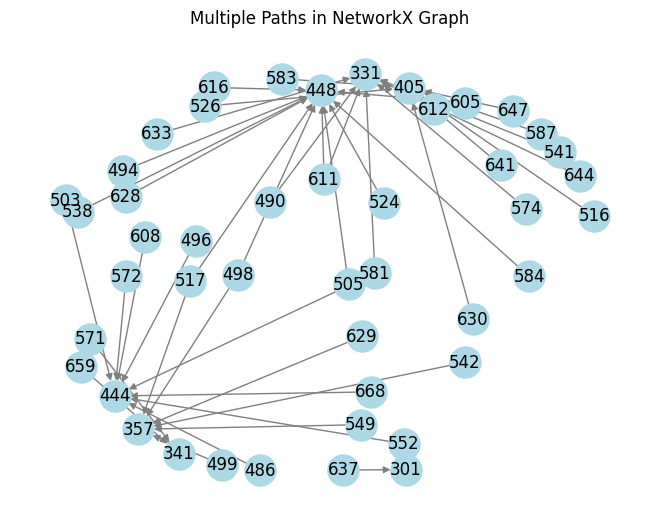

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

df_max_weight =0
df_max_weight = df_shortest_paths_with_weight['total_weight'].max()
df_max = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == df_max_weight]


# Example: multiple paths as lists of nodes
#paths = df_min_weight_paths['path']
paths = df_max['path']
# Create an empty graph
G = nx.DiGraph()

# Add edges from all paths
for path in paths:
# Add edges for consecutive pairs of nodes in the path
    edges_G = list(zip(path[:-1], path[1:]))
    G.add_edges_from(edges_G)

# Draw the graph
pos = nx.spring_layout(G, scale=2,k=0.85, iterations=50) # Layout algorithm for positions
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500)

# Optionally highlight each path in a different colour
# colors = ['red', 'green', 'blue', 'purple']
# for path, color in zip(paths, colors):
#     edges_zip = list(zip(path[:-1], path[1:]))
#     nx.draw_networkx_edges(G, pos, edgelist=edges_zip, width=2) #edge_color=color, width=2)
#plt.figure(figsize=(12, 8))
plt.title("Multiple Paths in NetworkX Graph")
plt.show()

In [ ]:
len(tier0_node_ids)

52

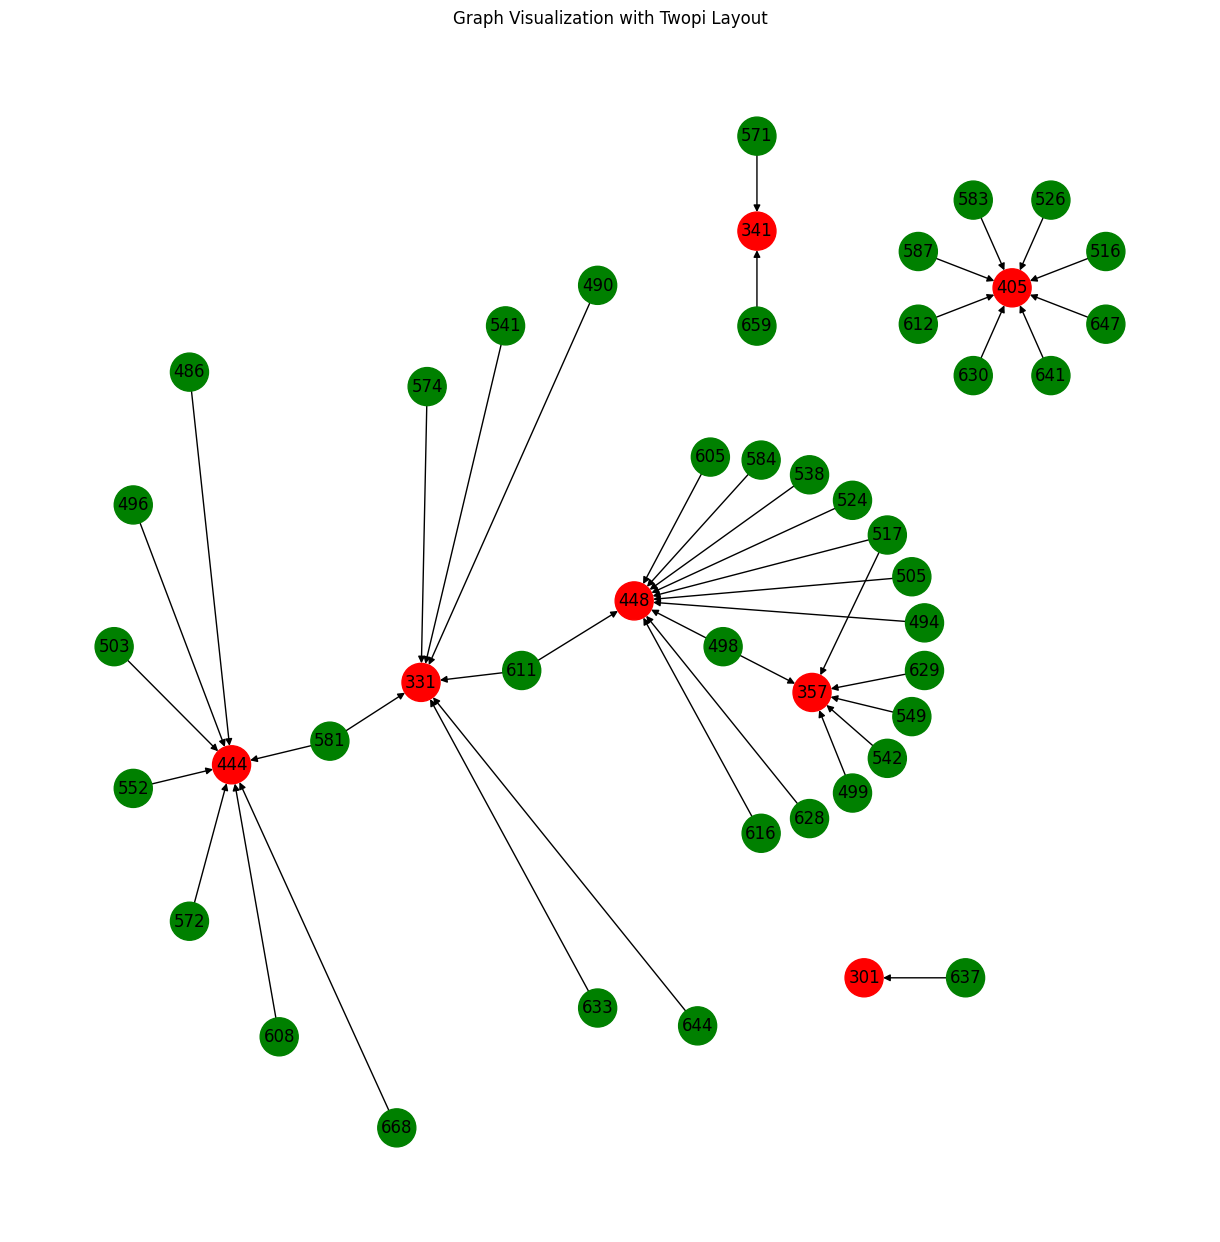

In [ ]:
import networkx as nx
import pydot
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import *
# graphviz is installed already, but need lib too
#!apt install libgraphviz-dev
#!pip install pygraphviz
# import pygraphviz as G_pgv

df=df_shortest_paths_with_weight
# df_max1 = []

# df_max1 = df[(df['source'].isin(tier2_node_ids))]# & (df['target'].isin(tier0_node_ids))]

# df_max_weight =0
# df_max_weight = df_shortest_paths_with_weight['total_weight'].max()
# df_max = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == df_max_weight]
#d = df_max[(df_max['source'].isin(tier2_node_ids)) & (df_max['target'].isin(tier0_node_ids)) & (~df_max['source'].isin(tier0_node_ids)) & (~df_max['target'].isin(tier2_node_ids))]

df_max_weight =0
df_max_weight = df_shortest_paths_with_weight['total_weight'].max()
df_max = df[(df['total_weight'] == df_max_weight) & (df['source'].isin(tier2_node_ids['id'].values)) &
            (df['target'].isin(tier0_node_ids['id'].values)) & (~df['source'].isin(tier0_node_ids['id'].values))]

#df.columns = ["source", "target", "path", "weight"]
#sample = df.sample(500, random_state = 1)
#sample.head(10)

G = nx.DiGraph()
#graph [root=new_node_id label=twopi]

for index, row in df_max.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight']

    # Add nodes for all nodes in the path
    for node in path:
        G.add_node(str(node))

    # Add edges for consecutive nodes in the path
    for i in range(len(path) - 1):
        G.add_edge(str(path[i]), str(path[i+1]))
colors = []
#Assuming node 4 is the one to highlight
for node in G.nodes():
    if (node) in str(tier0_node_ids['id']):
    #== new_node_id : # Ensure comparison is with string if nodes are strings
        colors.append('red')
        label ='Tier0'
        height=4
    elif (node) in tier1_node_ids['id']:
        colors.append('orange')
        height=2
    elif (node) in str(tier2_node_ids['id']):
        colors.append('green')
        height=1
    else:
        colors.append('yellow')

# Set graph attributes to control spacing
# G.graph['ranksep'] = '1.0' # Increase separation between ranks
# G.graph['nodesep'] = '4.0' # Increase separation between nodes

#G_pgv.graph_attr.update(root=new_node_id,ranksep='3.0',nodesep='2.0')
#G_pgv.draw('pytry.jpg',prog='twopi') # This line caused the error
plt.figure(figsize=(12, 12))
# Use pydot_layout with 'twopi' program
pos = pydot_layout(G, prog="twopi")#, root=str(new_node_id)) # Removed root as it might not exist in the graph
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=750, font_weight='normal')

plt.title("Graph Visualization with Twopi Layout")
graph_name_max = suf + '_max_twopi_graph.pdf'
plt.savefig(graph_name_max, format="pdf")
plt.show()

In [ ]:
# import networkx as nx
# import pydot
# import matplotlib.pyplot as plt
# from networkx.drawing.nx_pydot import *
# # graphviz is installed already, but need lib too
# #!apt install libgraphviz-dev
# #!pip install pygraphviz
# # import pygraphviz as G_pgv

# df=df_shortest_paths_with_weight
# # df_max1 = []

# # df_max1 = df[(df['source'].isin(tier2_node_ids))]# & (df['target'].isin(tier0_node_ids))]

# df_min_weight =0
# df_min_weight = df_shortest_paths_with_weight['total_weight'].min()
# df_min = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == df_max_weight]
# #d = df_max[(df_max['source'].isin(tier2_node_ids)) & (df_max['target'].isin(tier0_node_ids)) & (~df_max['source'].isin(tier0_node_ids)) & (~df_max['target'].isin(tier2_node_ids))]

# #df.columns = ["source", "target", "path", "weight"]
# #sample = df.sample(500, random_state = 1)
# #sample.head(10)

# G = nx.DiGraph()
# #graph [root=new_node_id label=twopi]

# for index, row in df_min.iterrows():
#     source = row['source']
#     target = row['target']
#     path = row['path']
#     weight = row['total_weight']

#     # Add nodes for all nodes in the path
#     for node in path:
#         G.add_node(str(node))

#     # Add edges for consecutive nodes in the path
#     for i in range(len(path) - 1):
#         G.add_edge(str(path[i]), str(path[i+1]))
# colors = []
# #Assuming node 4 is the one to highlight
# for node in G.nodes():
#     if (node) in str(tier0_node_ids['id']):
#     #== new_node_id : # Ensure comparison is with string if nodes are strings
#         colors.append('red')
#         label ='Tier0'
#         height=4
#     elif (node) in tier1_node_ids['id']:
#         colors.append('orange')
#         height=2
#     elif (node) in str(tier2_node_ids['id']):
#         colors.append('green')
#         height=1
#     else:
#         colors.append('yellow')

# # Set graph attributes to control spacing
# # G.graph['ranksep'] = '1.0' # Increase separation between ranks
# # G.graph['nodesep'] = '4.0' # Increase separation between nodes

# #G_pgv.graph_attr.update(root=new_node_id,ranksep='3.0',nodesep='2.0')
# #G_pgv.draw('pytry.jpg',prog='twopi') # This line caused the error
# plt.figure(figsize=(12, 12))
# # Use pydot_layout with 'twopi' program
# pos = pydot_layout(G, prog="twopi")#, root=str(new_node_id)) # Removed root as it might not exist in the graph
# nx.draw(G, pos, node_color=colors, with_labels=True, node_size=750, font_weight='normal')

# plt.title("Graph Visualization with Twopi Layout")
# graph_name_max = suf + '_min_twopi_graph.pdf'
# plt.savefig(graph_name_max, format="pdf")
# plt.show()

In [ ]:
print(nodes[nodes['id'] == 3167])
print(nodes[nodes['id'] == 3366])
# print(nodes[nodes['id'] == 6452])
# print(nodes[nodes['id'] == 6433])
# print(nodes[nodes['id'] == 6534])
# print(nodes[nodes['id'] == 6458])
# print(nodes[nodes['id'] == 6433])

Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []
Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []


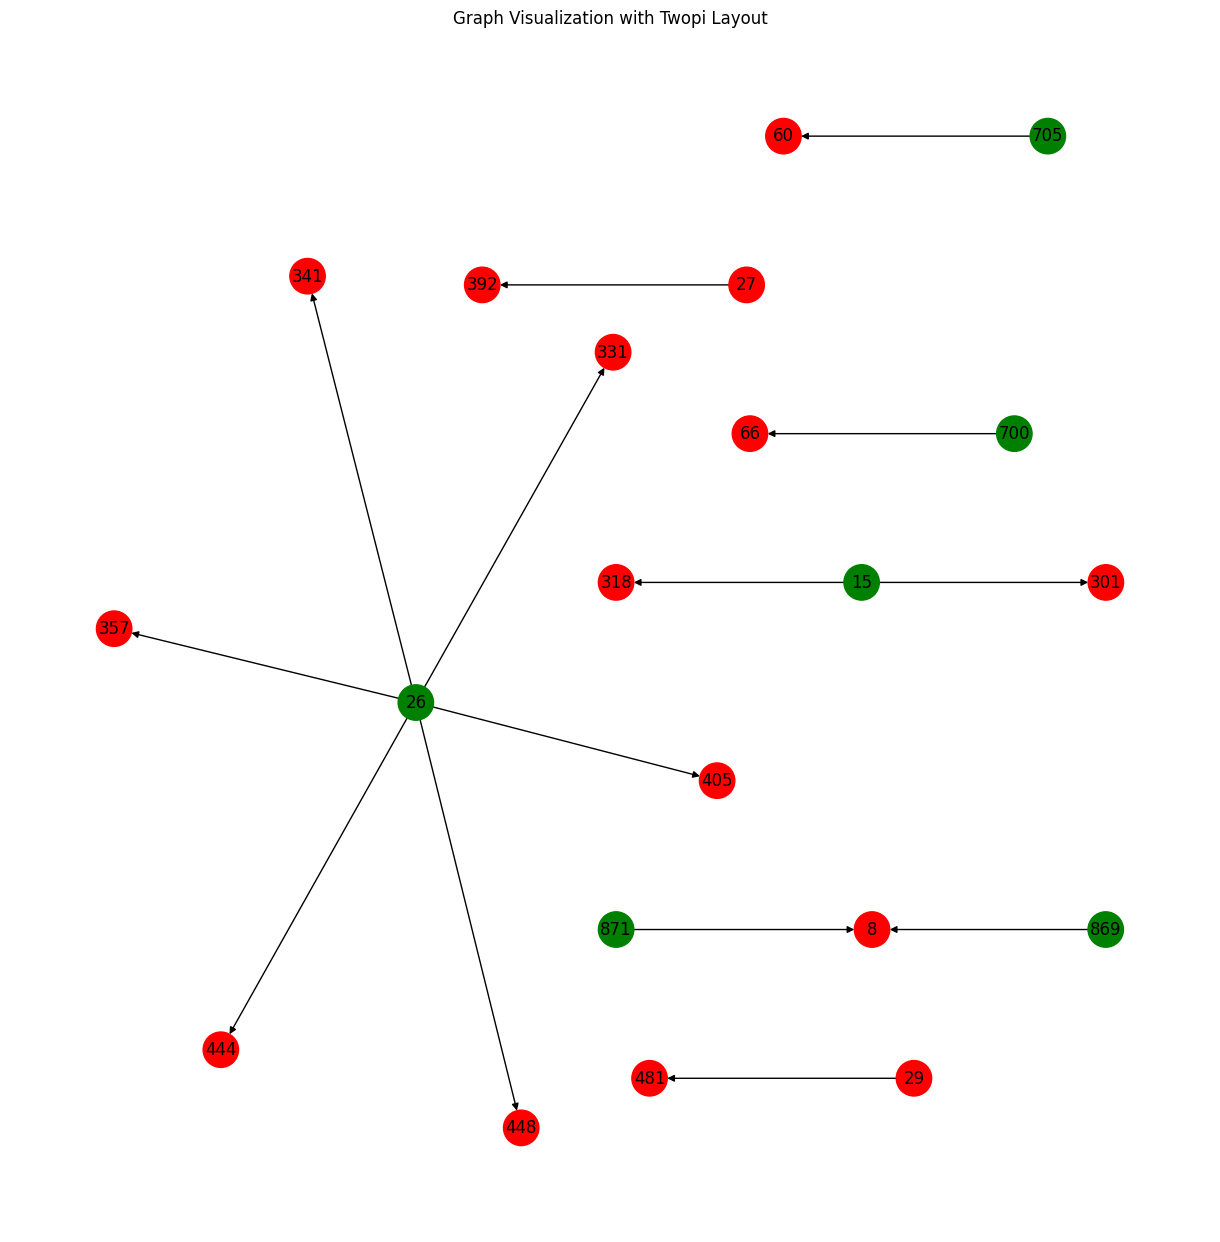

In [ ]:
import networkx as nx
import pydot
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import *
# graphviz is installed already, but need lib too
#!apt install libgraphviz-dev
#!pip install pygraphviz
# import pygraphviz as G_pgv

df=df_shortest_paths_with_weight

df_min_weight =0
df_min_weight = df_shortest_paths_with_weight['total_weight'].min()
df_min = df[(df['total_weight'] == df_min_weight) & (df['source'].isin(tier2_node_ids['id'].values)) &
            (df['target'].isin(tier0_node_ids['id'].values)) & (~df['source'].isin(tier0_node_ids['id'].values))]



G = nx.DiGraph()
#graph [root=new_node_id label=twopi]

for index, row in df_min.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight']

    # Add nodes for all nodes in the path
    for node in path:
        G.add_node(str(node))

    # Add edges for consecutive nodes in the path
    for i in range(len(path) - 1):
        G.add_edge(str(path[i]), str(path[i+1]))
colors = []
#Assuming node 4 is the one to highlight
for node in G.nodes():
    if (node) in str(tier0_node_ids['id'].values):
    #== new_node_id : # Ensure comparison is with string if nodes are strings
        colors.append('red')
        height=6
    elif (node) in (tier1_node_ids['id'].values):
        colors.append('orange')
        height=4
    elif (node) in str(tier2_node_ids['id'].values):
        colors.append('green')
        height=2
    else:
        colors.append('yellow')

# Set graph attributes to control spacing
G.graph['ranksep'] = '2.0' # Increase separation between ranks
G.graph['nodesep'] = '3.0' # Increase separation between nodes

#G_pgv.graph_attr.update(root=new_node_id,ranksep='3.0',nodesep='2.0')
#G_pgv.draw('pytry.jpg',prog='twopi') # This line caused the error
plt.figure(figsize=(12, 12))
# Use pydot_layout with 'twopi' program
#Options depend on GraphViz version but may include: ‘dot’, ‘twopi’, ‘fdp’, ‘sfdp’, ‘circo’
pos = pydot_layout(G, prog="sfdp", root=str(new_node_id)) # Removed root as it might not exist in the graph
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=650, font_weight='normal')

plt.title("Graph Visualization with Twopi Layout")
graph_name = suf + '_min_twopi_graph.pdf'
plt.savefig(graph_name, format="pdf")
plt.show()


# secure1k_min_graph.html

In [ ]:
import pandas as pd
from pyvis.network import Network
#pyvis.__version__

#Loading the data
#data = pd.read_csv("facebook_combined.txt", sep=" ", header=None)
df=df_shortest_paths_with_weight


df_min_weight =0
df_min_weight = df_shortest_paths_with_weight['total_weight'].min()
df_min = df[(df['total_weight'] == df_min_weight) & (df['source'].isin(tier2_node_ids['id'].values)) &
            (df['target'].isin(tier0_node_ids['id'].values)) & (~df['source'].isin(tier0_node_ids['id'].values))]
p0 = df_min.shape[0]
#in_line, remote
net = Network(notebook = True, cdn_resources = "remote",
                bgcolor = "#222222",
                font_color = "white",
                height = "750px",
                width = "100%",
                directed=True,
                select_menu=True
)
net.show_buttons(filter_=['physics'])
net.repulsion()
for index, row in df_min.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight'] # Changed 'total_weight' to 'weight'

    # Add nodes for all nodes in the path
    for node in path:
      if node in tier0_node_ids['id'].values:
        net.add_node(str(node), label=str(node), color='red') # Changed color to red for Tier 0
      elif node in tier1_node_ids['id'].values:
        net.add_node(str(node), label=str(node), color='orange')
      elif node in tier2_node_ids['id'].values:
        net.add_node(str(node), label=str(node), color='green')
      else:
        net.add_node(str(node), label=str(node), color='yellow')


    # Add edges for consecutive pairs of nodes in the path
    for i in range(len(path) - 1):
        lbl = " " + str(path[i]) + "->" +str(path[i+1])
        net.add_edge(str(path[i]), str(path[i+1]), weight=weight, title=f"Weight: {weight},{lbl}") # Added weight and title to edge#suf="vul1k"
# neighbor_map = net.get_adj_list()

# # add neighbor data to node hover data
# for node in got_net.nodes:
#                 node["title"] += " Neighbors:<br>" + "<br>".join([str(neighbor) for neighbor in neighbor_map[node["id"]]])
#                 node["value"] = len(neighbor_map[node["id"]])
graph_name = suf + '_min_graph.html'
#network.Network.set_options()
net.prep_notebook()
net.show_buttons(filter_=['nodes', 'edges', 'physics'])
net.show(graph_name)

secure1k_min_graph.html


In [ ]:
# from pyvis.network import Network
# import pandas as pd

# def get_node_label(node_id):
#     # Find the corresponding edge in the 'edges' DataFrame
#     nodeid = nodes[(nodes['id'] == node_id)]
#     if not nodeid.empty:
#         # Assuming there is only one edge with this start and end for simplicity in path finding
#         # If multiple edges exist, you might need to adjust based on which edge is part of the shortest path calculation
#         return nodeid.iloc[0]['l2']


# net = Network(height="750px", width="100%", bgcolor="#222222", font_color="white", notebook=True, cdn_resources = "remote")

# # set the physics layout of the network
# #net.force_atlas_2based(gravity=-50, central_gravity=0.01, spring_length=100, spring_strength=0.08, damping=0.4, overlap=0)
# net.barnes_hut(gravity=-1000, central_gravity=0.3, spring_length=250, spring_strength=0.001, damping=0.09, overlap=0)
# # net.hrepulsion(node_distance=120, central_gravity=0.0, spring_length=100, spring_strength=0.01, damping=0.09)
# # got_data = df_min
# # for index, row in got_data.iterrows():
# src = row['source']
# dst = row['target']
# w = row['total_weight']

# # sources = df_min['source']
# # targets = df_min['target']
# # weights = df_min['total_weight']

# edge_data = zip(src, dst, w)

# for e in edge_data:
#                 src = e[0]
#                 dst = e[1]
#                 w = e[2]
#                 tit_src = get_node_label(src)
#                 if src in (tier0_node_ids['id'].values):
#                     net.add_node(src, str(src), title=str(tit_src), color='#dd4b39')
#                 elif src in ( tier1_node_ids['id'].values):
#                     net.add_node(src, str(src), title=str(tit_src), color='#FFA500')
#                 elif src in (tier2_node_ids['id'].values):
#                     net.add_node(src, str(src), title=str(tit_src), color='#00ff1e')
#                 elif dst in (tier0_node_ids['id'].values):
#                     tit_src = get_node_label(dst)
#                     net.add_node(dst, str(dst), title=str(tit_dst), color='#dd4b39')
#                 elif dst in (tier1_node_ids['id'].values):
#                     tit_src = get_node_label(dst)
#                     net.add_node(dst, str(dst), title=str(tit_dst), color='#FFA500')
#                 elif dst in (tier2_node_ids['id'].values):
#                     tit_src = get_node_label(dst)
#                     net.add_node(dst, str(dst), title=str(tit_dst), color='#f3f10a')
#                 else:
#                     tit_src = get_node_label(src)
#                     net.add_node(dst, str(dst), title=str(tit_dst), color='#f3f10a')
#                 #     tit_dst = get_node_label(dst)

#                 # got_net.add_node(dst, str(dst), title=str(tit_dst))
#                 # got_net.add_edge(src, dst, value=w)

# neighbor_map = net.get_adj_list()

# # add neighbor data to node hover data
# for node in net.nodes:
#                 node["title"] += " Neighbors: <br>" + "<br>".join([str(neighbor) for neighbor in neighbor_map[node["id"]]])
#                 node["value"] = len(neighbor_map[node["id"]])

# # Explicitly toggle physics and show buttons
# graph_name = suf + '_min_graph-1.html'
# #network.Network.set_options()
# net.prep_notebook()
# net.show_buttons(filter_=['nodes', 'edges', 'physics'])
# net.show(graph_name)

TypeError: 'int' object is not iterable

# secure1k_max_graph.html

In [ ]:
df_max_weight =0
df_max_weight = df_shortest_paths_with_weight['total_weight'].max()
df_max = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == df_max_weight]


p1 = df_max.shape[0]

net = Network(notebook = True, cdn_resources = "remote",
                bgcolor = "#222222",
                font_color = "white",
                height = "750px",
                width = "100%",
                directed=True
)
net.repulsion(node_distance=150, central_gravity=0.2, spring_length=200, spring_strength=0.05, damping=0.09)

for index, row in df_max.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight'] # Changed 'total_weight' to 'weight'

    for node in path:
      if node in tier0_node_ids['id'].values:
        net.add_node(str(node), label=str(node), color='red') # Changed color to red for Tier 0
      elif node in tier1_node_ids['id'].values:
        net.add_node(str(node), label=str(node), color='orange')
      elif node in tier2_node_ids['id'].values:
        net.add_node(str(node), label=str(node), color='green')
      else:
        net.add_node(str(node), label=str(node), color='yellow')


    # Add edges for consecutive pairs of nodes in the path
    for i in range(len(path) - 1):
        lbl = str(path[i]) + "->" +str(path[i+1])
        net.add_edge(str(path[i]), str(path[i+1]), weight=weight, title=f"Weight: {weight},{lbl}") # Added weight and title to edge
graph_name = suf + '_max_graph.html'
net.prep_notebook()
net.show_buttons(filter_=['nodes', 'edges', 'physics'])
net.show(graph_name)

secure1k_max_graph.html


# New section

In [ ]:
for index, row in df_max.iterrows():
    path = row['path']
    print(f"Path: {path}")
    for node_id in path:
        # Find the node in the nodes DataFrame
        node_info = nodes[nodes['id'] == node_id]
        if not node_info.empty:
            # Get the properties and check for 'name' and Tier information
            properties = node_info.iloc[0]['properties']
            node_name = properties.get('name', 'N/A')
            is_tier0 = node_info.iloc[0]['Tier0'] == 1
            is_tier1 = node_info.iloc[0]['Tier1'] == 1
            is_tier2 = node_info.iloc[0]['Tier2'] == 1
            print(f"  Node ID: {node_id}, Name: {node_name}, Tier0: {is_tier0}, Tier1: {is_tier1}, Tier2: {is_tier2}")
        else:
            print(f"  Node ID: {node_id} not found in nodes DataFrame.")
    print("-" * 20)

In [ ]:
filtered_shortest_paths = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == 1]
display(filtered_shortest_paths)

,source,target,path,total_weight


In [ ]:
# Create a list to store the data for the table
table_data = []

# Iterate through the paths in df_max
for index, row in df_max.iterrows():
    path = row['path']
    # path_str = " -> ".join(map(str, path)) # Convert the path list to a string

    # Iterate through the nodes in the current path
    for node_id in path:
        # Find the node in the nodes DataFrame
        node_info = nodes[nodes['id'] == node_id]
        if not node_info.empty:
            properties = node_info.iloc[0]['properties']
            node_name = properties.get('name', 'N/A')
            is_tier0 = 1 if node_info.iloc[0]['Tier0'] == 1 else 0
            is_tier1 = 1 if node_info.iloc[0]['Tier1'] == 1 else 0
            is_tier2 = 1 if node_info.iloc[0]['Tier2'] == 1 else 0

            # Append the data as a dictionary to the list
            table_data.append({
                'Node Id': node_id, # Changed 'path' to 'Node Id' and stored node_id
                'Name': node_name,
                'Tier 0': is_tier0,
                'Tier 1': is_tier1,
                'Tier 2': is_tier2
            })

# Create a pandas DataFrame from the list of dictionaries
df_path_info = pd.DataFrame(table_data)

# Display the DataFrame
#display(df_path_info)

In [ ]:
latex_table = df_path_info.to_latex(index=False)

file_name = suf + "_max_paths_table.tex"

with open(file_name, 'w') as f:
    f.write(latex_table)

print(f"Table exported to {file_name}")

Table exported to secure1k_max_paths_table.tex


In [ ]:
# count_weight_2 = selected_edges[selected_edges['weight'] == 2].shape[0]
# print(f"Number of records in selected_edges with weight == 2: {count_weight_2}")

In [ ]:
# weight_distribution = selected_edges['weight'].value_counts().sort_index()
# print("Distribution of weights in selected_edges:")
# print(weight_distribution)

In [ ]:
from collections import Counter
#tier0_node_ids = tier0_node_ids.rename(columns={0: 'id'})

l1 = len(tier0_node_ids)
l2 = len(tier1_node_ids)
l3 = len(tier2_node_ids)
ln1 = len(nodes) -1
other  = ln1 - (l1 + l2 + l3)
amount_of_tier0_nodes = round(l1 / ln1 * 100,3)
print(f"% amount of tier0 nodes: {amount_of_tier0_nodes} %" )

amount_of_tier1_nodes = round(l2 /  ln1 * 100,3)
print(f"% amount of tier1 nodes: {amount_of_tier1_nodes} %" )

amount_of_tier2_nodes = round(l3 /  ln1 * 100,3)
print(f"% amount of tier2 nodes: {amount_of_tier2_nodes} %" )
tot = amount_of_tier2_nodes + amount_of_tier1_nodes + amount_of_tier0_nodes
print(f"% amount of total nodes: {tot} %" )



# l2_counts = Counter(nodes['l2'])
# display(l2_counts)
l2_counts = Counter(nodes['l2'])

# Create a DataFrame from the Counter
l2_counts_df = pd.DataFrame(l2_counts.items(), columns=['Value', 'Count'])
l2_counts_df = l2_counts_df.sort_values(by='Count')

# Convert the DataFrame to a LaTeX table format
latex_table = l2_counts_df.to_latex(index=False)

# Display the LaTeX table output
print(latex_table)


cnt_min_paths = round(p0 / ln1 * 100,3)
cnt_max_paths = round(p1 / ln1 * 100,3)

print(f"amount of min paths: {p0}: {cnt_min_paths} %" )
print(f"amount of max paths: {p1}: {cnt_max_paths} %" )

% amount of tier0 nodes: 4.009 %
% amount of tier1 nodes: 4.395 %
% amount of tier2 nodes: 72.398 %
% amount of total nodes: 80.80199999999999 %
\begin{tabular}{lr}
\toprule
Value & Count \\
\midrule
Domain & 1 \\
Container & 1 \\
ALL_T0 & 1 \\
OU & 44 \\
GPO & 181 \\
User & 205 \\
Computer & 209 \\
Group & 656 \\
\bottomrule
\end{tabular}

amount of min paths: 14: 1.079 %
amount of max paths: 43: 3.315 %


In [ ]:
# Get unique values from the 'l2' column with their counts
l2_counts = nodes['l2'].value_counts().to_dict()

# Create the filename
file_name = suf + "_nodes.json"

# Save the unique values and counts as JSON
with open(file_name, 'w') as f:
    json.dump(l2_counts, f, indent=4)

print(f"Unique 'l2' values with counts exported to {file_name}")

Unique 'l2' values with counts exported to secure1k_nodes.json


In [ ]:
# Get unique values from the 'label' column with their counts
label_counts = edges['label'].value_counts().to_dict()

# Create the filename
file_name = suf + "_label.json"

# Save the unique values and counts as JSON
with open(file_name, 'w') as f:
    json.dump(label_counts, f, indent=4)

print(f"Unique 'label' values with counts exported to {file_name}")

Unique 'label' values with counts exported to secure1k_label.json


In [ ]:
count_matching_edges = edges[edges['source'].isin(tier2_node_ids['id'])]
print(f"Number of records where edge['source'] is in tier2_node_ids: {count_matching_edges}")

In [ ]:
print(nodes[nodes['id'] == 7715])
print(nodes[nodes['id'] == 5388])
# print(nodes[nodes['id'] == 6452])
# print(nodes[nodes['id'] == 6433])
# print(nodes[nodes['id'] == 6534])
# print(nodes[nodes['id'] == 6458])
# print(nodes[nodes['id'] == 6433])

Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []
Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []


In [ ]:
tier0_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: (
            any(
                term in x.get('distinguishedname', '')
                for term in ['TIER 0', 'Tier 0', 'T0', 'TIER0','CN=Enterprise Admins,', 'CN=Domain Admins,', 'CN=Administrator,']
            )
            or  # Use 'or' to combine the conditions
            (
                re.search(r'.*-5[0-9]{2}$', x.get('objectid', '')) is not None and
                x.get('highvalue', False) == True and
                x.get('admincount', False) == True
            )
        )
    )
]['id'].tolist()

print(f"Updated Tier 0 Node IDs: {tier0_node_ids}")
print(f"Number of Tier 0 nodes: {len(tier0_node_ids)}")

Updated Tier 0 Node IDs: [4, 7, 8, 9, 10, 36, 38, 40, 59, 60, 65, 66, 72, 286, 295, 296, 301, 303, 305, 306, 307, 318, 324, 331, 341, 357, 392, 405, 444, 448, 457, 458, 467, 469, 481, 527, 530, 531, 532, 553, 607, 610, 625, 631, 632, 640, 645, 653, 663, 686, 692, 9999]
Number of Tier 0 nodes: 52


In [ ]:
import json

# Create a dictionary with the requested format
output_data = {
    suf: {
        "values": {
            "Ratio": ratio,
            "ratio_min": ratio_subgraph_min,
            "ratio_max": ratio_subgraph_max
        }
    }
}

# Create the filename
file_name = suf + "ratios.json"

# Save the dictionary as a JSON file
with open(file_name, 'w') as f:
    json.dump(output_data, f, indent=4)

print(f"Values exported to {file_name}")

Values exported to secure1k_values.json


In [ ]:
import json
# sub_graph_min = round(p0/ln1 *100, 3)
# print(f"sub_graph_min: {sub_graph_min}%")
# sub_graph_max = round(p1/ln1 *100, 3)
# print(f"sub_graph_max: {sub_graph_max}%")

edges_len = len(edges['source'])
print(f"edges_len: {edges_len}")
ratio = round(ln1/edges_len *100, 2)
print(f"ratio: {ratio}%")

ratio_subgraph_min = round(p0/edges_len *100, 2)
print(f"ratio_subgraph_min: {ratio_subgraph_min}%")

ratio_subgraph_max = round(p1/edges_len *100, 2)
print(f"ratio_subgraph_max: {ratio_subgraph_max}%")



# Create a dictionary with the requested format
output_data = {
    suf: {
        "values": {
            "Ratio": ratio,
            "ratio_min": ratio_subgraph_min,
            "ratio_max": ratio_subgraph_max
        }
    }
}

# Create the filename
file_name = suf + "ratios.json"

# Save the dictionary as a JSON file
with open(file_name, 'w') as f:
    json.dump(output_data, f, indent=4)

print(f"Values exported to {file_name}")

edges_len: 4026
ratio: 32.22%
ratio_subgraph_min: 0.35%
ratio_subgraph_max: 1.07%
Values exported to secure1kratios.json
